# 3주차 · 센서 시계열 탐색
데이터: 식각 장비 FDC 트레이스 (수업용 생성 데이터)

---

## 오늘의 상황

식각 장비는 웨이퍼 한 장을 처리하는 60초 동안 센서 값을 1초에 한 번씩 기록합니다.
이걸 FDC(Fault Detection and Classification) 트레이스라고 부릅니다.

장비 엔지니어가 이렇게 말합니다.

> 불량 난 웨이퍼들이 있는데, 트레이스를 보면 뭔가 이상한 게 보일 겁니다. 찾아주세요.

오늘은 트레이스를 그려보고, 60줄짜리 시계열을 모델이 먹을 수 있는 한 줄로 줄이는 것까지 합니다.
모델은 다음 주에 만듭니다.

## 오늘 할 것

1. 트레이스 열어보기
2. 웨이퍼 한 장을 눈으로 보기
3. 스텝 구조 파악하기
4. 정상과 이상을 겹쳐 그리기
5. 웨이퍼 한 장을 한 줄로 줄이기
6. 기울기라는 특징 만들기
7. 어떤 특징이 어떤 이상을 잡는가

## 규칙

`# TODO` 가 붙은 셀만 작성하면 됩니다. 각 미션 뒤에 자가진단 셀이 있으니
`[통과]` 가 뜰 때까지 스스로 고쳐보세요. 막히면 물어보되 먼저 15분은 혼자 붙들어 보세요.
정답을 베끼는 것보다 틀리고 고치는 과정이 점수에 반영됩니다.

---

## 준비

In [1]:
# 이 셀은 그대로 실행하세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

_have = {f.name for f in fm.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if _f in _have:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

DATA = Path('../../data/etch_fdc')   # 폴더를 옮겼다면 이 줄만 고치세요

def check(name, cond, hint=''):
    if cond:
        print('[통과] ' + name)
    else:
        print('[실패] ' + name + (('  ->  ' + str(hint)) if hint else ''))

print('폰트:', plt.rcParams['font.family'][0], '| 데이터 폴더:', DATA.exists())

폰트: Malgun Gothic | 데이터 폴더: False


---

## 미션 1 · 트레이스 열어보기

지난 두 주와 데이터가 다릅니다. 지금까지는 웨이퍼 한 장에 값이 한 줄이었는데,
이번에는 웨이퍼 한 장이 **60줄**입니다. 1초에 한 번씩 60초를 기록했기 때문입니다.
이런 걸 시계열이라고 합니다.

`traces.csv` 와 `wafer_info.csv` 를 불러오고 구조를 확인하세요.

센서는 여덟 개입니다.

| 컬럼 | 뜻 | 단위 |
|---|---|---|
| `rf_forward_W` | RF 순방향 전력 | W |
| `rf_reflected_W` | RF 반사 전력. 정합이 나쁘면 올라간다 | W |
| `chamber_pressure_mTorr` | 챔버 압력 | mTorr |
| `ar_flow_sccm` | 아르곤 유량 | sccm |
| `cf4_flow_sccm` | CF4 유량 | sccm |
| `esc_temp_C` | 정전척 온도 | degC |
| `he_backside_Torr` | 웨이퍼 뒷면 헬륨 압력 | Torr |
| `endpoint_intensity` | 종점 검출 발광 세기 | a.u. |

In [2]:
# 미션 1: CSV 파일 두 개를 표(DataFrame)로 읽습니다.
# tr은 1초 단위 센서 기록, wi는 웨이퍼별 기본 정보입니다.
tr = pd.read_csv('traces.csv')
# timestamp는 글자가 아닌 날짜/시간으로 읽어 두면 나중에 시간 계산이 편합니다.
wi = pd.read_csv('wafer_info.csv', parse_dates=['timestamp'])

# TODO 1-2: 각각의 크기, 웨이퍼 수, 웨이퍼 한 장당 행 수를 출력
#   힌트: tr.wafer_id.nunique() 로 웨이퍼 수를 세고, 전체 행 수를 그것으로 나누세요
# shape는 (행 개수, 열 개수)입니다.
print('traces 크기:', tr.shape)
print('wafer_info 크기:', wi.shape)

# nunique()는 중복을 빼고 wafer_id가 몇 개인지 셉니다.
wafer_count = tr['wafer_id'].nunique()
rows_per_wafer = len(tr) / wafer_count
print('웨이퍼 수:', wafer_count)
print('웨이퍼 한 장당 기록 수:', rows_per_wafer)





# TODO 1-3: 이상 유형(fault_type)별 웨이퍼 수
#   힌트: value_counts(). 자가진단이 fault_counts.get('NORMAL') 을 봅니다
# normal을 제외한 모든 fault_type 의 웨이퍼 수를 출력하세요
# value_counts()는 이상 유형별 개수를 세어 줍니다.
fault_counts = wi['fault_type'].value_counts()
print('이상 유형별 웨이퍼 수:')
print(fault_counts)

traces 크기: (24000, 11)
wafer_info 크기: (400, 6)
웨이퍼 수: 400
웨이퍼 한 장당 기록 수: 60.0
이상 유형별 웨이퍼 수:
fault_type
NORMAL            316
RF_UNSTABLE        30
PRESSURE_DRIFT     30
GAS_LEAK           24
Name: count, dtype: int64


자가진단 1 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [3]:
check('traces 24000행 11열', tr is not None and tr.shape == (24000, 11), None if tr is None else tr.shape)
check('웨이퍼 400장', wi is not None and len(wi) == 400)
check('장당 60행', tr is not None and len(tr) // tr.wafer_id.nunique() == 60)
check('정상 316장', fault_counts is not None and fault_counts.get('NORMAL') == 316, None if fault_counts is None else dict(fault_counts))

[통과] traces 24000행 11열
[통과] 웨이퍼 400장
[통과] 장당 60행
[통과] 정상 316장


---

## 미션 2 · 웨이퍼 한 장을 눈으로 보기

정상 웨이퍼 `WF0001` 을 골라 여덟 개 센서를 각각 그려보세요.
`plt.subplots(4, 2)` 로 여덟 칸을 만들고 한 칸에 센서 하나씩 넣습니다.

그리고 나서 그래프를 보며 답해 보세요. 60초 동안 무슨 일이 일어났습니까.
값이 계단처럼 바뀌는 지점이 보입니까.

숫자 표만 보고 시계열을 이해하려 들면 안 됩니다. 일단 그려야 합니다.

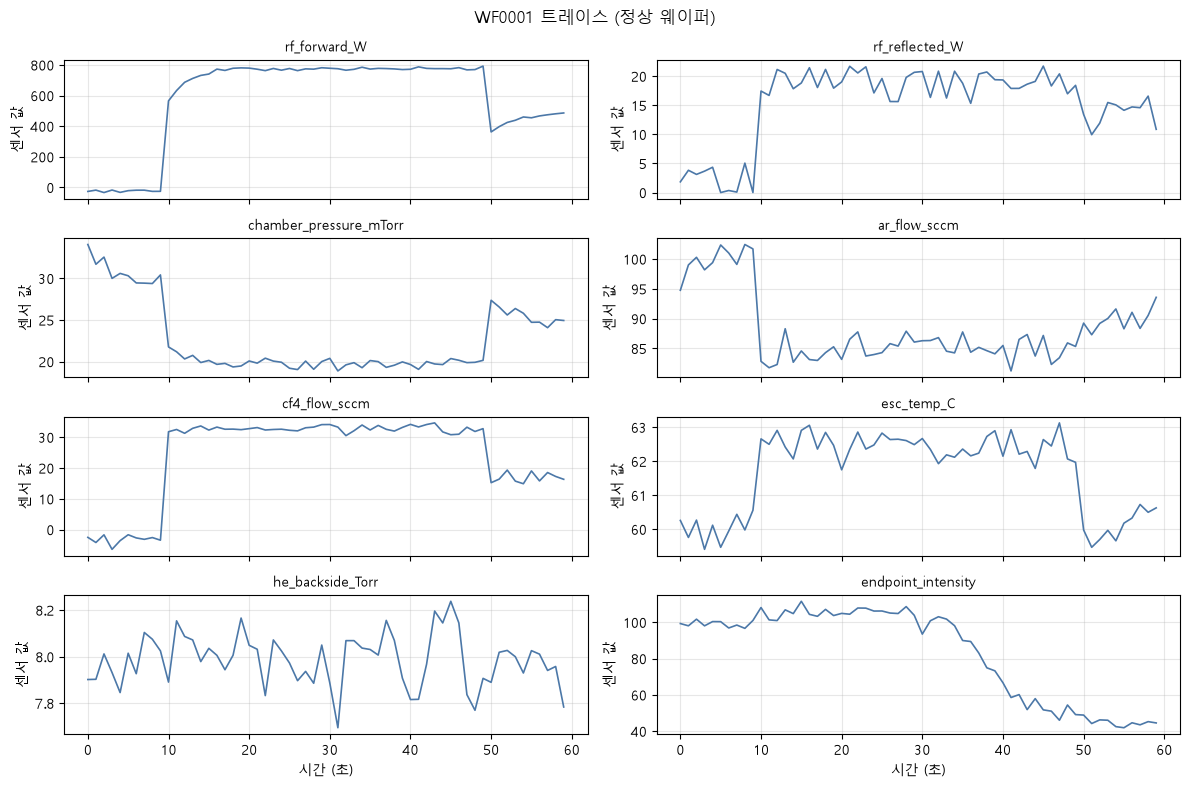

In [4]:
# 미션 2-1: 조건에 맞는 행만 골라 정상 웨이퍼 한 장을 만듭니다.
one = tr[tr['wafer_id'] == 'WF0001']


# TODO 2-2: 4행 2열 subplot 에 센서 8개를 각각 그리기
#   x축은 t_sec, 각 칸에 센서 이름을 제목으로
#   힌트: plt.subplots(4, 2, sharex=True) 가 돌려주는 axes 는 4x2 배열입니다.
#         axes.ravel() 로 8칸짜리 한 줄로 편 다음 SENSORS 와 zip 하세요
SENSORS = ['rf_forward_W', 'rf_reflected_W', 'chamber_pressure_mTorr', 'ar_flow_sccm',
           'cf4_flow_sccm', 'esc_temp_C', 'he_backside_Torr', 'endpoint_intensity']
fig, axes = plt.subplots(4, 2, sharex=True, figsize=(12, 8))


# ravel()은 4x2 축 배열을 왼쪽부터 8칸의 한 줄로 바꿉니다.
# zip()으로 각 그래프 칸(ax)에 센서 이름(sensor)을 하나씩 짝지어 줍니다.
for ax, sensor in zip(axes.ravel(), SENSORS):
    ax.plot(one['t_sec'], one[sensor], linewidth=1.2, color='#4C78A8')
    ax.set_title(sensor, fontsize=10)
    ax.set_ylabel('센서 값')
    ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('시간 (초)')
fig.suptitle('WF0001 트레이스 (정상 웨이퍼)')
plt.tight_layout()
plt.show()

자가진단 2 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [5]:
check('WF0001 60행', one is not None and len(one) == 60, None if one is None else len(one))
check('센서 8개 지정', len(SENSORS) == 8)

[통과] WF0001 60행
[통과] 센서 8개 지정


---

## 미션 3 · 스텝 구조 파악하기

레시피는 세 단계로 되어 있습니다.

- `Stabilize` 0~9초. 가스를 넣고 압력을 잡는 구간. RF는 아직 꺼져 있습니다.
- `MainEtch` 10~49초. RF를 켜고 실제로 깎는 구간. **이상은 거의 여기서 나옵니다.**
- `Overetch` 50~59초. 남은 부분을 마저 깎는 구간.

스텝별로 센서 평균을 구해 표로 만들고, 각 스텝이 몇 초인지 확인하세요.

In [6]:
# TODO 3-1: 스텝별 지속 시간 (웨이퍼 한 장 기준)
#   one 을 step 으로 묶어 행 수를 세면 됩니다. 1행이 1초입니다.
#   공정 순서를 지키려면 groupby 에 sort=False 를 주세요
# groupby('step')은 같은 공정 단계끼리 묶고, size()는 각 묶음의 행 수를 셉니다.
step_len = one.groupby('step', sort=False).size()
print('스텝별 시간(초):')
print(step_len)

# TODO 3-2: 스텝별 센서 평균 (전체 웨이퍼)
#   전체 tr 을 step 으로 묶고 SENSORS 컬럼의 평균을 내면 3행짜리 표가 됩니다
# 센서 8개만 선택한 뒤, 스텝별 평균을 계산합니다.
by_step = tr.groupby('step', sort=False)[SENSORS].mean()
print('스텝별 센서 평균:')
print(by_step)

스텝별 시간(초):
step
Stabilize    10
MainEtch     40
Overetch     10
dtype: int64
스텝별 센서 평균:
           rf_forward_W  rf_reflected_W  chamber_pressure_mTorr  ar_flow_sccm  \
step                                                                            
Stabilize     -0.147810        2.997383               31.054164     98.461595   
MainEtch     784.709233       19.317596               20.254119     79.893280   
Overetch     462.415012       12.771823               25.897942     88.631673   

           cf4_flow_sccm  esc_temp_C  he_backside_Torr  endpoint_intensity  
step                                                                        
Stabilize      -0.117100   62.060702          7.996557           99.998242  
MainEtch       39.469171   64.557312          8.000230           84.503706  
Overetch       19.624482   62.050880          8.000845           45.008330  


자가진단 3 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [7]:
check('Stabilize 10초', step_len is not None and step_len.get('Stabilize') == 10)
check('MainEtch 40초', step_len is not None and step_len.get('MainEtch') == 40)
check('Overetch 10초', step_len is not None and step_len.get('Overetch') == 10)
check('스텝별 평균 3행', by_step is not None and len(by_step) == 3)

[통과] Stabilize 10초
[통과] MainEtch 40초
[통과] Overetch 10초
[통과] 스텝별 평균 3행


---

## 미션 4 · 정상과 이상을 겹쳐 그리기

이상 유형이 세 가지 있습니다.

- `RF_UNSTABLE` — RF 정합이 나빠져 반사 전력이 튄다
- `PRESSURE_DRIFT` — 배기 경로가 막혀 압력이 서서히 올라간다
- `GAS_LEAK` — MFC 유량이 부족해 CF4가 덜 들어간다

각 유형에서 웨이퍼를 한 장씩 골라 정상 웨이퍼와 **같은 그림에 겹쳐** 그리세요.
유형마다 가장 잘 드러날 것 같은 센서를 하나씩 고르면 됩니다.

겹쳐 그려야 차이가 보입니다. 따로 그리면 축이 달라져서 비교가 안 됩니다.

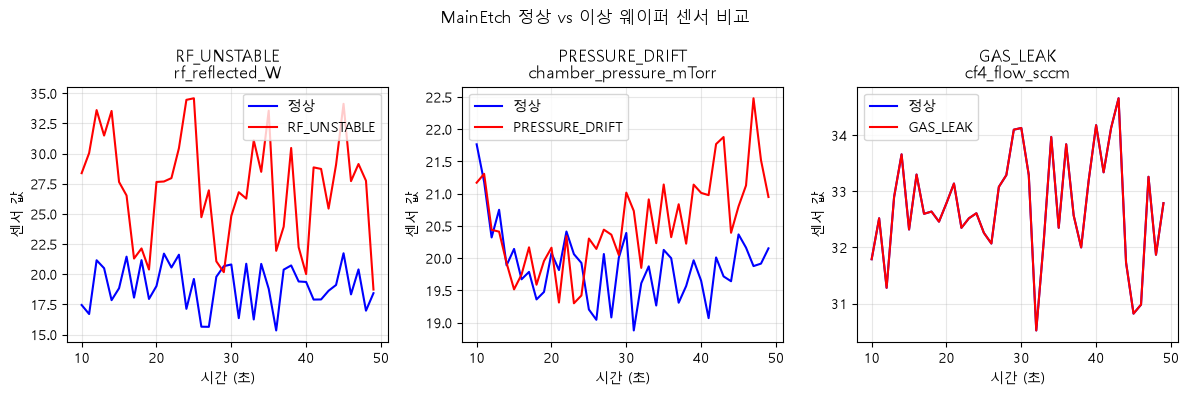

In [8]:
# TODO 4-1: 유형별로 웨이퍼 하나씩 고르기
#   힌트: wi[wi.fault_type == 'RF_UNSTABLE'].wafer_id.iloc[0]
#   RF_UNSTABLE, PRESSURE_DRIFT, GAS_LEAK 세 개를 {유형: wafer_id} 딕셔너리로
# iloc[0]은 조건에 맞는 웨이퍼 중 첫 번째 한 장을 뜻합니다.
# 딕셔너리는 '이상 유형: 선택한 웨이퍼 ID' 형태로 저장합니다.
picks = {
    'RF_UNSTABLE': wi[wi.fault_type == 'RF_UNSTABLE'].wafer_id.iloc[0],
    'PRESSURE_DRIFT': wi[wi.fault_type == 'PRESSURE_DRIFT'].wafer_id.iloc[0],
    'GAS_LEAK': wi[wi.fault_type == 'GAS_LEAK'].wafer_id.iloc[0]
}



# TODO 4-2: 유형마다 알맞은 센서를 골라 정상과 겹쳐 그리기
#   1행 3열 subplot 을 쓰고, MainEtch 구간만 그려도 좋습니다
#   센서는 이상 이름에서 짐작할 수 있습니다. RF 가 불안하면 어느 신호를 봐야 할까요.
#   정상 웨이퍼와 반드시 같은 축에 겹쳐 그리세요. 따로 그리면 y축 범위가 달라
#   차이가 있어도 안 보입니다

sensor_map = {
    'RF_UNSTABLE': 'rf_reflected_W',
    'PRESSURE_DRIFT': 'chamber_pressure_mTorr',
    'GAS_LEAK': 'cf4_flow_sccm'
}

# 비교 대상인 정상 웨이퍼는 반복문 밖에서 한 번만 준비합니다.
normal_data = tr[(tr['wafer_id'] == 'WF0001') & (tr['step'] == 'MainEtch')]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# enumerate()의 i는 0, 1, 2로 증가하며 각 그래프 칸을 고르는 번호입니다.
for i, (fault_type, wafer_id) in enumerate(picks.items()):
    sensor = sensor_map[fault_type]  # 이상 유형에 맞는 센서 선택
    fault_data = tr[(tr['wafer_id'] == wafer_id) & (tr['step'] == 'MainEtch')]

    axes[i].plot(normal_data.t_sec, normal_data[sensor], label='정상', color='blue')
    axes[i].plot(fault_data.t_sec, fault_data[sensor], label=fault_type, color='red')
    axes[i].set_title(f'{fault_type}\n{sensor}')
    axes[i].set_xlabel('시간 (초)')
    axes[i].set_ylabel('센서 값')
    axes[i].grid(alpha=0.3)
    axes[i].legend()
fig.suptitle('MainEtch 정상 vs 이상 웨이퍼 센서 비교')
plt.tight_layout()
plt.show()







자가진단 4 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [9]:
check('세 유형 선택', picks is not None and len(picks) == 3)
check('선택한 웨이퍼가 실제 그 유형인가',
      picks is not None and all(wi.set_index('wafer_id').fault_type[v] == k for k, v in picks.items()))

[통과] 세 유형 선택
[통과] 선택한 웨이퍼가 실제 그 유형인가


---

## 미션 5 · 웨이퍼 한 장을 한 줄로 줄이기

모델에 넣으려면 웨이퍼 한 장이 한 줄이어야 합니다. 지금은 60줄입니다.
그래서 **요약통계**로 줄입니다.

MainEtch 구간만 골라서, 센서 여덟 개 각각의 평균·표준편차·최솟값·최댓값을 구하세요.
8 × 4 = 32개 값이 나옵니다. 이게 웨이퍼 한 장을 대표하는 한 줄이 됩니다.

MainEtch만 쓰는 이유는 이상이 거의 거기서 나오기 때문입니다.
Stabilize 는 RF가 꺼져 있어 넣어봐야 잡음만 늘어납니다.

In [10]:
# TODO 5-1: MainEtch 구간만 뽑기 (16000행이어야 합니다)
# 실제 식각이 진행되는 MainEtch 행만 남깁니다.
main = tr[tr['step'] == 'MainEtch']

# TODO 5-2: 웨이퍼별로 센서 8개의 mean/std/min/max 구하기
#   힌트: main.groupby('wafer_id')[SENSORS].agg(['mean','std','min','max'])
# 웨이퍼별로 8개 센서를 묶고, 평균·표준편차·최솟값·최댓값을 계산합니다.
# agg는 여러 요약 계산을 한 번에 적용하는 기능입니다.
feat = main.groupby('wafer_id')[SENSORS].agg(['mean', 'std', 'min', 'max'])

# TODO 5-3: 컬럼 이름을 rf_forward_W_mean 처럼 한 층으로 펴기
#   힌트: feat.columns = ['_'.join(c) for c in feat.columns]
# 현재 열 이름은 ('rf_forward_W', 'mean')처럼 두 층입니다.
# join으로 두 이름을 이어 'rf_forward_W_mean' 한 줄 이름으로 바꿉니다.
feat.columns = ['_'.join(column) for column in feat.columns]

자가진단 5 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [11]:
check('MainEtch 16000행', main is not None and len(main) == 16000, None if main is None else len(main))
check('특징 400행 32열', feat is not None and feat.shape == (400, 32), None if feat is None else feat.shape)
check('컬럼명 평탄화', feat is not None and 'rf_reflected_W_max' in feat.columns)

[통과] MainEtch 16000행
[통과] 특징 400행 32열
[통과] 컬럼명 평탄화


---

## 미션 6 · 기울기라는 특징 만들기

`PRESSURE_DRIFT` 는 압력이 **서서히 올라가는** 이상입니다.
그런데 평균이나 최댓값으로는 잘 안 잡힙니다. 평균은 오르든 내리든 비슷하게 나오니까요.

필요한 건 **기울기**입니다. 시간에 대해 직선을 맞춰서 그 기울기를 구합니다.

```python
np.polyfit(x, y, 1)[0]    # 1차 다항식을 맞추고 기울기만 꺼냄
```

웨이퍼별로 MainEtch 구간 압력의 기울기를 구해 `pressure_slope` 컬럼으로 붙이세요.

이렇게 도메인을 알고 특징을 새로 만드는 걸 특징 공학이라고 합니다.
다음 주에 이 특징이 제일 중요하게 나옵니다.

In [12]:
# TODO 6-1: 웨이퍼별 압력 기울기
# 함수로 따로 만들면 lambda 한 줄보다 '무엇을 하는지' 읽기 쉽습니다.
def get_pressure_slope(one_wafer):
    # polyfit(시간, 압력, 1)은 직선을 맞춥니다. 결과의 첫 번째 값([0])이 기울기입니다.
    return np.polyfit(one_wafer['t_sec'], one_wafer['chamber_pressure_mTorr'], 1)[0]

# 웨이퍼별로 위 함수를 적용해 압력 기울기 하나씩을 구합니다.
slope = main.groupby('wafer_id').apply(get_pressure_slope)

# TODO 6-2: slope를 feat 에  pressure_slope 컬럼으로 붙이고 wafer_info 와 합치기
#   feat 의 인덱스가 wafer_id 이므로 reset_index() 한 뒤 wi 와 merge 하세요
# reset_index()로 wafer_id를 일반 열로 꺼내고, 기울기 열에 알아보기 쉬운 이름을 붙입니다.
slope_df = slope.reset_index(name='pressure_slope')
# merge는 wafer_id가 같은 행끼리 두 표를 옆으로 합칩니다.
data = pd.merge(feat.reset_index(), slope_df, on='wafer_id')


#   결과는 400행이고 fault_type 컬럼이 들어 있어야 합니다
# 마지막으로 각 웨이퍼의 정상/이상 유형도 붙입니다.
data = pd.merge(data, wi[['wafer_id', 'fault_type']], on='wafer_id')

# TODO 6-3: 이상 유형별 기울기 평균 출력
#   PRESSURE_DRIFT 만 튀는지 확인하세요
print(data.groupby('fault_type')['pressure_slope'].mean())

fault_type
GAS_LEAK         -0.022182
NORMAL           -0.023598
PRESSURE_DRIFT    0.031061
RF_UNSTABLE      -0.023769
Name: pressure_slope, dtype: float64


자가진단 6 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [13]:
check('기울기 400개', slope is not None and len(slope) == 400)
check('data 결합', data is not None and 'fault_type' in data.columns and len(data) == 400)
check('DRIFT 기울기가 가장 큼',
      data is not None and data.groupby('fault_type').pressure_slope.mean().idxmax() == 'PRESSURE_DRIFT')

[통과] 기울기 400개
[통과] data 결합
[통과] DRIFT 기울기가 가장 큼


---

## 미션 7 · 어떤 특징이 어떤 이상을 잡는가

이제 특징 33개가 생겼습니다. 어떤 게 어떤 이상에 반응하는지 봅시다.

아래 세 특징을 골라 이상 유형별 박스플롯을 그리세요.

- `rf_reflected_W_max`
- `pressure_slope`
- `cf4_flow_sccm_mean`

그리고 나서 각 특징이 어느 유형을 잘 갈라주는지, 잘 못 갈라주는 유형은 없는지 보세요.
특히 `GAS_LEAK` 을 눈여겨보세요. 정상과 얼마나 겹칩니까.

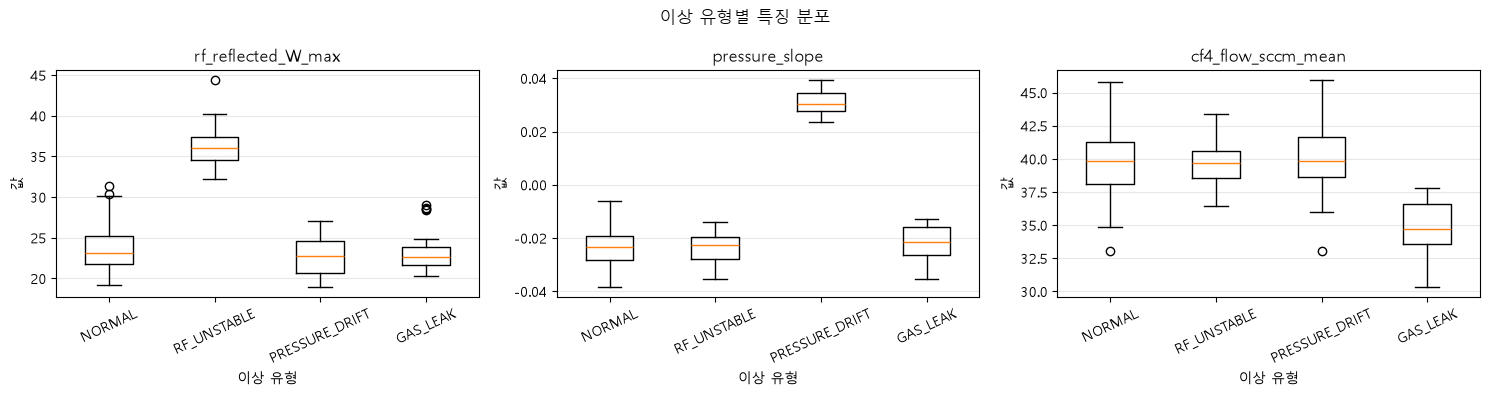

                rf_reflected_W_max  pressure_slope  cf4_flow_sccm_mean
fault_type                                                            
GAS_LEAK                 23.515833       -0.022182           34.867635
NORMAL                   23.519272       -0.023598           39.760036
PRESSURE_DRIFT           22.710667        0.031061           40.000875
RF_UNSTABLE              36.144333       -0.023769           39.554925


In [14]:
# TODO 7-1: 세 특징을 이상 유형별 박스플롯으로 (1행 3열)
#   ORDER 순서로 그리면 표와 그림을 나란히 읽기 좋습니다
PICK = ['rf_reflected_W_max', 'pressure_slope', 'cf4_flow_sccm_mean']
ORDER = ['NORMAL', 'RF_UNSTABLE', 'PRESSURE_DRIFT', 'GAS_LEAK']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 그래프 칸 하나와 특징 하나를 차례대로 짝지어 반복합니다.
for ax, feature in zip(axes, PICK):
    # 박스플롯은 유형별 값 묶음이 필요하므로 빈 리스트에 하나씩 넣습니다.
    values = []
    for fault_type in ORDER:
        group_values = data.loc[data['fault_type'] == fault_type, feature]
        values.append(group_values)
    ax.boxplot(values, tick_labels=ORDER)
    ax.set_title(feature)
    ax.set_xlabel('이상 유형')
    ax.set_ylabel('값')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('이상 유형별 특징 분포')
plt.tight_layout()
plt.show()

# TODO 7-2: 유형별 평균을 표로
#   fault_type 으로 묶어 PICK 세 컬럼의 평균을 내세요 (4행 3열)
# 유형별로 묶은 뒤, 선택한 세 특징의 평균을 표로 만듭니다.
summary = data.groupby('fault_type')[PICK].mean()
print(summary)

# TODO 7-3: GAS_LEAK 은 정상과 얼마나 겹칩니까? (주석으로)
#   답: GAS_LEAK 의 cf4_flow_sccm_mean 값은 정상과 거의 겹칩니다. 박스플롯을 보면 GAS_LEAK 의 중앙값과 사분위 범위가 NORMAL 과 유사하며, 두 그룹의 분포가 상당히 겹쳐 있습니다.

자가진단 7 — 실행해서 모두 `[통과]` 인지 확인하세요.

In [15]:
check('요약표 4행', summary is not None and len(summary) == 4)
check('RF 반사전력 최대는 RF_UNSTABLE 이 1위',
      summary is not None and summary.rf_reflected_W_max.idxmax() == 'RF_UNSTABLE')
check('CF4 평균은 GAS_LEAK 이 최소',
      summary is not None and summary.cf4_flow_sccm_mean.idxmin() == 'GAS_LEAK')

[통과] 요약표 4행
[통과] RF 반사전력 최대는 RF_UNSTABLE 이 1위
[통과] CF4 평균은 GAS_LEAK 이 최소


---

## 미션 8 · 정리해서 쓰기

코드가 아니라 글입니다. 숫자를 근거로 인용하세요.

---

**1. 이 데이터는 지난 두 주와 무엇이 다른가**

웨이퍼 한 장이 몇 줄입니까. 왜 그렇습니까.

답: 웨이퍼 한 장은 60줄입니다. 전체 트레이스가 24,000줄이고 웨이퍼가 400장이므로 24,000 ÷ 400 = 60입니다. 즉, 각 센서를 60초 동안 1초마다 기록한 시계열 데이터라는 점이 지난 두 주의 웨이퍼당 한 줄 데이터와 다릅니다.

**2. 60줄을 1줄로 줄일 때 무엇을 잃는가**

평균과 표준편차만 남기면 사라지는 정보가 있습니다. 무엇입니까.

답: 평균과 표준편차만 남기면 시간 순서와 값이 변한 시점이 사라집니다. 예를 들어 같은 평균이라도 압력이 계속 상승한 경우, 순간적으로 튄 뒤 돌아온 경우, 또는 공정 단계마다 다른 변화가 있었는지는 알 수 없습니다. 최솟값·최댓값을 함께 써도 변화의 순서와 지속 시간은 복원할 수 없습니다.

**3. 왜 MainEtch 구간만 썼는가**

Stabilize 와 Overetch 를 뺀 이유를 설명하세요.

답: 이상은 실제 식각이 진행되는 MainEtch 구간에서 주로 발생합니다. Stabilize는 RF가 꺼져 있는 10초 구간이고, Overetch는 마무리 10초 구간이므로 이들을 포함하면 이상과 무관한 값과 잡음이 늘어납니다. 따라서 40초인 MainEtch만 사용해 이상 신호에 집중했습니다.

**4. 기울기는 왜 따로 만들어야 했나**

평균이나 최댓값으로 `PRESSURE_DRIFT` 를 못 잡는 이유를 쓰세요.

답: PRESSURE_DRIFT는 압력이 시간에 따라 서서히 올라가는 이상이므로 평균이나 최댓값만으로는 변화 방향과 속도를 충분히 표현하지 못합니다. 압력 기울기를 만들자 PRESSURE_DRIFT의 평균은 +0.0311 mTorr/s였고, 정상은 -0.0236 mTorr/s여서 방향까지 뚜렷하게 구분되었습니다.

**5. 세 가지 이상 중 어느 것이 가장 찾기 어려울 것 같은가**

미션 7의 박스플롯을 근거로 답하세요.

답: 세 유형 중 GAS_LEAK이 가장 찾기 어려울 가능성이 큽니다. CF4 유량 평균은 GAS_LEAK이 34.87 sccm로 정상 39.76 sccm보다 낮지만, GAS_LEAK의 최댓값 37.81과 정상의 최솟값 33.05 사이에 겹치는 구간이 있습니다. 반면 RF_UNSTABLE의 반사전력 최대 평균은 36.14 W로 정상 23.52 W보다 크게 높고, PRESSURE_DRIFT의 기울기도 양수로 명확합니다.

**6. 이 특징들로 놓치게 될 이상은 무엇일까**

요약통계 33개로는 잡을 수 없는 이상을 상상해서 쓰세요. 최소 두 가지.
힌트: 순간적으로 튀었다 돌아오는 이상은? 두 센서의 관계가 틀어지는 이상은?

답: 첫째, 아주 짧게 한두 번만 튄 뒤 정상으로 돌아오는 이상은 40초 구간의 평균·표준편차·최솟값·최댓값에 묻혀 놓칠 수 있습니다. 둘째, 각 센서의 개별 요약값은 정상 범위여도 RF 전력과 압력처럼 두 센서가 함께 변해야 할 관계가 틀어지는 이상은 잡기 어렵습니다. 또한 같은 요약통계를 가지지만 변화가 발생한 시점이나 파형이 다른 이상도 구분하지 못합니다.

---

### 제출 전 확인

- [ ] 자가진단이 모두 `[통과]` 인가
- [ ] 그래프 네 개(센서 8칸, 겹쳐 그리기, 박스플롯)에 제목과 축 이름이 있는가
- [ ] 미션 8의 여섯 항목을 본인 문장으로 채웠는가
- [ ] 커널 재시작 후 전체 실행이 오류 없이 끝나는가
- [ ] 파일명을 `W03_학번_이름.ipynb` 로 바꿨는가